# DeepSeek-V4-Flash-Vision-Exp — vision on 4x CMP 170HX (SM80), IN PROGRESS

| Status | Value |
|---|---|
| Vision gate on this PP4 + DSpark k=6 recipe | not run yet, no PASS |
| Reference-runtime vision PASS (different topology) | 0.9 tok/s decode, correctness only |
| Text-path performance (same checkpoint, this recipe) | see the PP4 text notebook |
| Blocker | forward-porting SM80 sparse-MLA onto the pinned vision head |

No proof image yet: this recipe has not produced a passing vision run.

```
hf download deepseek-ai/DeepSeek-V4-Flash-Vision-Exp --revision 86f746b36186f0e567729a5c06a8c918caba82a9 --local-dir <weights>
```

[Reference PASS: DeepSeek-V4-Flash-Vision-Exp-CMP-170HX](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX)


# DeepSeek-V4-Flash-Vision-Exp — vision on 4-card PP4 vLLM (IN PROGRESS)

Vision correctness on the SM80 PP4 + DSpark k=6 fork that serves the text
path in `2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm.ipynb`.
This work is in progress; there is no PASS on this recipe yet.

Reading order: TL;DR, then visible results, then reproduce steps.
Attempt history and architecture detail are in the collapsed appendix.

Evidence: `results/2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm/`,
`docs/LESSONS.md`, and the reference-runtime PASS in
[DeepSeek-V4-Flash-Vision-Exp-CMP-170HX](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX)
(`results/receipts/vision-ready.json`).


In [1]:
import os

EXPERIMENT = "2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm"
RESULTS_DIR = os.path.join("..", "results", EXPERIMENT)
LIVE = False
VISION_ENDPOINT = os.environ.get("VISION_ENDPOINT", "http://127.0.0.1:18099/v1")

print(f"experiment      : {EXPERIMENT}")
print(f"results_dir     : {RESULTS_DIR}")
print(f"LIVE            : {LIVE}")
print("status          : IN PROGRESS (Path 3, forward-porting SM80 sparse-MLA onto the pinned Vision head), gates pending")


experiment      : 2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm
results_dir     : ../results/2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm
LIVE            : False
status          : IN PROGRESS (Path 3, forward-porting SM80 sparse-MLA onto the pinned Vision head), gates pending


In [2]:
import hashlib
import json
import os

from IPython.display import display, Markdown, Image as IPyImage


def load_receipt(name, results_dir=RESULTS_DIR):
    path = os.path.join(results_dir, name)
    if not os.path.exists(path):
        print(f"no receipts yet: {path} does not exist")
        return None
    with open(path) as f:
        data = json.load(f)
    if isinstance(data, dict) and data.get("status") == "not run":
        print(f"no receipts yet: {path} is a placeholder stub ({data.get('note', '')})")
        return None
    return data


def render_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown("\n".join(lines)))


def sha256_of(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()


gates = load_receipt("vision-gates.json")
ladder = load_receipt("ladder.json")


no receipts yet: ../results/2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm/vision-gates.json is a placeholder stub (Gates pending. This recipe (vision on vLLM PP4/DSpark, SM80) has not booted a server; the reference-runtime prior-evidence receipt is separate and lives under prior-evidence/vision-ready.json.)
no receipts yet: ../results/2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm/ladder.json is a placeholder stub (Gates pending; no ladder has run on this recipe.)


## 1. TL;DR

**Status: vision on vLLM PP4 (SM80, DSpark k=6) = IN PROGRESS (Path 3).
Gates pending.** The two Route B attempts against the pinned reference
Vision head both failed before serving a request (see the appendix). No
boot attempt has been made yet on Path 3, the reverse-port of vision onto
the working SM80 fork. The row below labeled "prior evidence" is a PASS
on a *different* runtime (reference TP4, not this PP4/DSpark recipe) and
is not a result for this recipe.


In [3]:
key_metrics = [
    ("Vision on PP4/DSpark (this recipe)", "IN PROGRESS, no boot attempt yet on Path 3; not run"),
    ("Route B attempt 1 (pinned reference Vision head, this hardware)", "FAILED, no SM80 sparse-MLA attention backend in the pinned tree"),
    ("Prior evidence: vision PASS, reference TP4 runtime (different recipe)", "PASS, 135 prompt / 20 completion tokens, about 0.9 tok/s decode"),
    ("Text-path decode, c=1 (this recipe, PP4 + DSpark k=6)", "97.41 tok/s (median of 3)"),
    ("Text-path aggregate decode, best passing level (c=8)", "220.17 tok/s (median of 3)"),
    ("Text-path uncached prefill, 2,941 tokens", "2,352.24 tok/s warm"),
    ("Text-path warm streaming TTFT", "0.394 s"),
    ("Text-path cold boot to ready", "41.9 min"),
]
render_table(["Metric", "Value"], key_metrics)


| Metric | Value |
|---|---|
| Vision on PP4/DSpark (this recipe) | IN PROGRESS, no boot attempt yet on Path 3; not run |
| Route B attempt 1 (pinned reference Vision head, this hardware) | FAILED, no SM80 sparse-MLA attention backend in the pinned tree |
| Prior evidence: vision PASS, reference TP4 runtime (different recipe) | PASS, 135 prompt / 20 completion tokens, about 0.9 tok/s decode |
| Text-path decode, c=1 (this recipe, PP4 + DSpark k=6) | 97.41 tok/s (median of 3) |
| Text-path aggregate decode, best passing level (c=8) | 220.17 tok/s (median of 3) |
| Text-path uncached prefill, 2,941 tokens | 2,352.24 tok/s warm |
| Text-path warm streaming TTFT | 0.394 s |
| Text-path cold boot to ready | 41.9 min |

In [4]:
pins = [
    ("Model revision", "deepseek-ai/DeepSeek-V4-Flash-Vision-Exp @ 86f746b36186f0e567729a5c06a8c918caba82a9"),
    ("Fork lineage (working text-path fork)", "allover326/vllm-dsa-mtp-sm80 base + SM80 patches + PP4/DSpark patches (8 files, receipts/vllm-source-patches.diff)"),
    ("Vision path (in progress)", "Path 3: reverse-port an SM80 sparse-MLA backend onto this same fork; not yet built"),
    ("GHCR image tag (text path only)", "ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-sm80-20260902"),
    ("GHCR image tag (vision path)", "not published yet"),
    ("Driver", "610.43.03 (measured on this fleet's 4-card node)"),
    ("PP partition", "11,11,11,10 (VLLM_PP_LAYER_PARTITION)"),
    ("Speculative decoding k", "6 (DSpark, num_speculative_tokens=6)"),
    ("KV cache dtype", "fp8"),
]
render_table(["Pin", "Value"], pins)


| Pin | Value |
|---|---|
| Model revision | deepseek-ai/DeepSeek-V4-Flash-Vision-Exp @ 86f746b36186f0e567729a5c06a8c918caba82a9 |
| Fork lineage (working text-path fork) | allover326/vllm-dsa-mtp-sm80 base + SM80 patches + PP4/DSpark patches (8 files, receipts/vllm-source-patches.diff) |
| Vision path (in progress) | Path 3: reverse-port an SM80 sparse-MLA backend onto this same fork; not yet built |
| GHCR image tag (text path only) | ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-sm80-20260902 |
| GHCR image tag (vision path) | not published yet |
| Driver | 610.43.03 (measured on this fleet's 4-card node) |
| PP partition | 11,11,11,10 (VLLM_PP_LAYER_PARTITION) |
| Speculative decoding k | 6 (DSpark, num_speculative_tokens=6) |
| KV cache dtype | fp8 |

## 2. Visible results

Nothing in this section is a result for the PP4/DSpark recipe yet. The
fixtures, corpus, and gate cells below are wired and ready to run the
moment Path 3 boots. What is shown here instead: the prior evidence of a
vision PASS on a different runtime, for context.

### 2.1 Prior evidence: vision PASS on the reference TP4 runtime

Before Path 3 existed, the reference TP4 runtime (with its own SM80
fallback patches, unrelated to the PP4/DSpark fork above) completed the
first real-image inference of this checkpoint on Ampere hardware. Source:
`results/receipts/vision-ready.json` in the public
[DeepSeek-V4-Flash-Vision-Exp-CMP-170HX](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX)
repository, copied into `prior-evidence/vision-ready.json` here.


In [5]:
prior = json.load(open(os.path.join(RESULTS_DIR, "prior-evidence", "vision-ready.json")))
prior_rows = [
    ("Gate", prior["gate"]),
    ("Topology", prior["topology"]),
    ("Model id", prior["model_id"]),
    ("Image-completion HTTP status", prior["gates"]["image_completion"]["http"]),
    ("Prompt tokens", prior["gates"]["image_completion"]["prompt_tokens"]),
    ("Completion tokens", prior["gates"]["image_completion"]["completion_tokens"]),
    ("Fixture", prior["gates"]["image_completion"]["fixture"]),
    ("Answer", prior["gates"]["image_completion"]["answer"]),
    ("SM80 fixes applied on that runtime", "; ".join(prior["fixes"])),
    ("GPU memory per card (MiB)", prior["health"]["gpu_mem_per_card_mib"]),
    ("Xid/ECC", prior["health"]["xid_ecc"]),
]
render_table(["Field", "Value"], prior_rows)
print("Decode rate for this gate is reported elsewhere (docs/LESSONS.md, README.md) as about 0.9 tok/s;")
print("this receipt itself carries token counts and http status, not a computed rate.")


| Field | Value |
|---|---|
| Gate | vision-ready |
| Topology | TP4, 4x CMP 170HX (SM80, 64 GiB each) |
| Model id | deepseek-v4-flash-vision-exp-cmp-170hx |
| Image-completion HTTP status | 200 |
| Prompt tokens | 135 |
| Completion tokens | 20 |
| Fixture | 64x64 PNG gradient (red-to-green vertical, blue constant); colors absent from prompt |
| Answer | The dominant colors are pink, yellow, blue, and green, blending smoothly in a gradient. |
| SM80 fixes applied on that runtime | b70923c block-scale broadcast + pure-torch hadamard; f4e9772 image placeholder import fix; 5d0d1ca native multimodal encoding route |
| GPU memory per card (MiB) | 44408 |
| Xid/ECC | none |

Decode rate for this gate is reported elsewhere (docs/LESSONS.md, README.md) as about 0.9 tok/s;
this receipt itself carries token counts and http status, not a computed rate.


The gradient image below is regenerated to match the receipt's
description ("64x64 PNG gradient, red-to-green vertical, blue constant";
colors were absent from the prompt). It is not byte-identical to the
original fixture, which was not preserved in the evidence bundle.


regenerated fixture: ../results/2026-09-02-deepseek-v4-flash-vision-exp-4card-vision-pp4-vllm/fixtures/prior_evidence_gradient_regenerated.png  sha256=0801b8d180ab81d822fa94676d1bf3023fa874159a8dd3af9b07e538ec803fc8


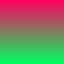

question: What are the dominant colors in this image?
model answer (from the receipt): The dominant colors are pink, yellow, blue, and green, blending smoothly in a gradient.


In [6]:
from PIL import Image

FIXTURES_DIR = os.path.join(RESULTS_DIR, "fixtures")
os.makedirs(FIXTURES_DIR, exist_ok=True)
SIZE = 64

regenerated = Image.new("RGB", (SIZE, SIZE))
for y in range(SIZE):
    t = y / (SIZE - 1)
    r = int(255 * (1 - t))
    g = int(255 * t)
    for x in range(SIZE):
        regenerated.putpixel((x, y), (r, g, 96))
path = os.path.join(FIXTURES_DIR, "prior_evidence_gradient_regenerated.png")
regenerated.save(path)
print(f"regenerated fixture: {path}  sha256={sha256_of(path)}")
display(IPyImage(filename=path))
print(f"question: What are the dominant colors in this image?")
print(f"model answer (from the receipt): {prior['gates']['image_completion']['answer']}")


### 2.2 Golden corpus (image prompts)

The correctness gate every vision patch runs against, copied from the
corpus's public schema (question and keyword only):


In [7]:
golden_corpus = [
    ("img01_solid_red", "What is the single dominant color in this image? Answer with exactly one color word.", "red"),
    ("img02_solid_blue", "What is the single dominant color in this image? Answer with exactly one color word.", "blue"),
    ("img03_gradient_red_green", "This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma.", "red, green"),
    ("img04_gradient_blue_yellow", "This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma.", "blue, yellow"),
    ("img05_checkerboard", "This is an 8 by 8 checkerboard pattern. How many black squares does it contain? Answer with a number only.", "32"),
    ("img06_three_circles", "How many circles are shown in this image? Answer with a number only.", "3, three"),
    ("img07_five_squares", "How many squares are shown in this image? Answer with a number only.", "5, five"),
    ("img08_word_hello", "What single word is written in this image? Answer with just the word.", "hello"),
    ("img09_split_red_blue", "This image is split into a left half and a right half, each a solid color. What color is the LEFT half? Answer with one word.", "red"),
    ("img10_triangle", "What geometric shape is shown in this image? Answer with one word.", "triangle"),
]
render_table(["Id", "Question", "Expected keyword(s)"], golden_corpus)


| Id | Question | Expected keyword(s) |
|---|---|---|
| img01_solid_red | What is the single dominant color in this image? Answer with exactly one color word. | red |
| img02_solid_blue | What is the single dominant color in this image? Answer with exactly one color word. | blue |
| img03_gradient_red_green | This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma. | red, green |
| img04_gradient_blue_yellow | This image is a horizontal color gradient. Name the two colors it blends between, left color first, separated by a comma. | blue, yellow |
| img05_checkerboard | This is an 8 by 8 checkerboard pattern. How many black squares does it contain? Answer with a number only. | 32 |
| img06_three_circles | How many circles are shown in this image? Answer with a number only. | 3, three |
| img07_five_squares | How many squares are shown in this image? Answer with a number only. | 5, five |
| img08_word_hello | What single word is written in this image? Answer with just the word. | hello |
| img09_split_red_blue | This image is split into a left half and a right half, each a solid color. What color is the LEFT half? Answer with one word. | red |
| img10_triangle | What geometric shape is shown in this image? Answer with one word. | triangle |

### 2.3 Functional gates on this recipe

Wired for the moment Path 3 boots; not run yet.


In [8]:
if LIVE:
    raise RuntimeError("Path 3 has not booted a server yet, nothing to call")
if gates is not None and gates.get("rows"):
    for row in gates["rows"]:
        print(row)
else:
    print("no receipts yet: this recipe has not run the functional gates")


no receipts yet: this recipe has not run the functional gates


### 2.4 Measurements

The text-path ladder from the same PP4 + DSpark k=6 recipe is the
baseline row; there is no vision (text+image) row yet.


In [9]:
text_only_ladder = [
    ("text-only", 1, 97.41, 97.42, "PASS"),
    ("text-only", 2, 103.66, 57.37, "PASS"),
    ("text-only", 4, 165.53, 66.92, "PASS"),
    ("text-only", 8, 220.17, 35.96, "PASS"),
    ("text-only", 16, None, None, "FAIL (device-side assert, rank 3 draft path)"),
    ("text+one-image", "-", "-", "-", "not run"),
]
render_table(
    ["Prompt type", "Concurrency", "Aggregate median (tok/s)", "Per-request median (tok/s)", "Status"],
    text_only_ladder,
)
print("Source for the text-only row: 2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm.ipynb")


| Prompt type | Concurrency | Aggregate median (tok/s) | Per-request median (tok/s) | Status |
|---|---|---|---|---|
| text-only | 1 | 97.41 | 97.42 | PASS |
| text-only | 2 | 103.66 | 57.37 | PASS |
| text-only | 4 | 165.53 | 66.92 | PASS |
| text-only | 8 | 220.17 | 35.96 | PASS |
| text-only | 16 | None | None | FAIL (device-side assert, rank 3 draft path) |
| text+one-image | - | - | - | not run |

Source for the text-only row: 2026-09-02-deepseek-v4-flash-vision-exp-4card-pp4-vllm.ipynb


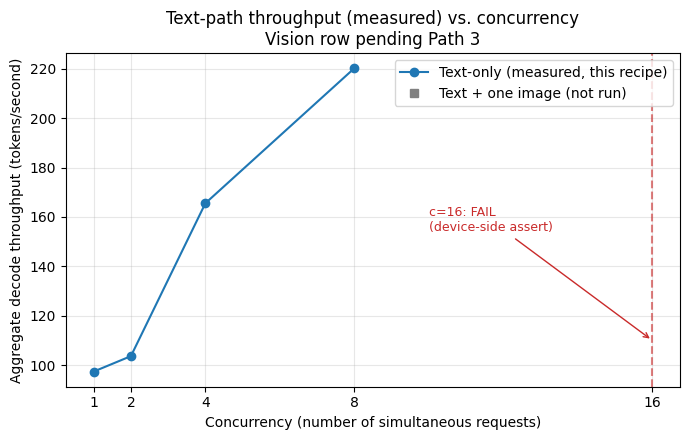

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
x = [1, 2, 4, 8]
y = [97.41, 103.66, 165.53, 220.17]
ax.plot(x, y, marker="o", label="Text-only (measured, this recipe)")
ax.axvline(16, color="#c92a2a", linestyle="--", alpha=0.6)
ax.annotate("c=16: FAIL\n(device-side assert)", xy=(16, max(y) * 0.5),
            xytext=(10, max(y) * 0.7), fontsize=9, color="#c92a2a",
            arrowprops=dict(arrowstyle="->", color="#c92a2a"))
ax.plot([], [], marker="s", linestyle="none", color="gray", label="Text + one image (not run)")
ax.set_xlabel("Concurrency (number of simultaneous requests)")
ax.set_ylabel("Aggregate decode throughput (tokens/second)")
ax.set_title("Text-path throughput (measured) vs. concurrency\nVision row pending Path 3")
ax.set_xticks([1, 2, 4, 8, 16])
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## 3. Reproduce

**Hardware.** 4x NVIDIA CMP 170HX (SM80, 64 GiB HBM2e each, no NVLink),
PCIe Gen1 x16 per card as measured on this rig, 180 W power limit per
card, forced airflow.

**Text-path image (working today):**

```bash
docker pull ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-sm80-20260902
```

**Vision-path image:** not published. Path 3 has not produced a build.

**Launch (text path, working; vision-capable launch pending Path 3):**

```bash
docker run -d --name <container> --gpus '"device=0,1,2,3"' \
  -e VLLM_PP_LAYER_PARTITION=11,11,11,10 \
  -v <model-storage>/deepseek-v4-flash-vision-exp@86f746b3:/model:ro \
  --shm-size=16g -p 18098:8000 \
  ghcr.io/pixelml/club-170hx:vllm-deepseek-v4-sm80-20260902 \
  vllm serve /model --served-model-name dsv4v \
  --pipeline-parallel-size 4 --kv-cache-dtype fp8 \
  --block-size 256 --max-model-len 16384 --max-num-batched-tokens 2048 \
  --max-num-seqs 8 --tokenizer-mode deepseek_v4 \
  --speculative-config '{"method":"dspark","num_speculative_tokens":6}'
```

**Snapshot.** `deepseek-ai/DeepSeek-V4-Flash-Vision-Exp`, revision
`86f746b36186f0e567729a5c06a8c918caba82a9`, 48 safetensors shards, about
156 GiB. Verify shard count and byte total against a manifest before
serving.

**Bench command.** `run_protocol.sh` from the text-path evidence bundle
drives `bench_harness.py`; this notebook's functional-gate cells drive
the same endpoint's vision path once Path 3 boots.

**Expected boot time.** About 42 minutes cold from NFS-backed shared
storage on the text-path recipe (2,515 s measured). No boot has
completed yet on Path 3.


## 4. Appendix

<details>
<summary>Attempt history, architecture, limitations (click to expand)</summary>

### 4.1 How the approach evolved

Three paths have been considered for vision on this SM80 fleet:

1. **Path 1: patch the pinned reference Vision head's PP-rank input
   handling.** Root cause found and fixed: the modular V1 runner
   unconditionally nulled `input_ids` on every non-first pipeline rank,
   but DeepSeek V4 Vision's MoE gate needs raw `input_ids` on every rank
   for its image-token routing. The fix (bind-mounted, no rebuild)
   worked: the boot got past model load and into kernel warmup.
2. **Path 2: same idea under tensor parallelism (TP4) instead of PP4.**
   Not attempted; source inspection showed it would hit the identical
   next blocker (below), so the second and final boot attempt in the
   two-boot budget was not spent confirming a predictable failure.
3. **Path 3: reverse-port an SM80 sparse-MLA attention backend onto the
   fork that already serves text on this hardware.** In progress. The
   old SM80 fork already has a working `ampere_sparse.py` backend; the
   pinned reference Vision head does not. Estimated 18-30 engineering
   hours across 8-10 files, medium-high risk. No build has started.

### 4.2 What went wrong: Route B, attempt 7 (2026-09-02)

One of two budgeted boot attempts, spent on Path 1.

**Blocker 1 (fixed).** `vllm/v1/worker/gpu/model_runner.py`,
`execute_model()`: non-first PP ranks always set `input_ids = None`.
DeepSeek V4 Vision sets `requires_raw_input_tokens = True` because its
MoE gate applies `bias_vl` image-token routing using raw `input_ids` on
every rank, not only rank 0 (`vllm/models/deepseek_v4/nvidia/model.py:991`
raises `ValueError("DeepSeek V4 vision MoE routing requires input_ids.")`
otherwise). Patch: null `input_ids` only when the model does not set
that flag. Verified live in the running container; `py_compile` passed
before mount. This patch is correct and should be kept for any future
attempt on this codebase.

**Blocker 2 (not fixed, stopped the attempt).** Past model load, kernel
warmup raised `RuntimeError: vllm._flashmla_C is not available`. The
pinned Vision head's attention-backend selector only branches on compute
capability major version 12 (FlashInfer sparse MLA); everything else
defaults to `DeepseekV4FlashMLAAttention`. Neither concrete NVIDIA
sparse-MLA backend in this tree (`nvidia/flashmla.py`: major in [9, 10];
`nvidia/flashinfer_sparse.py`: major in [10, 12]) covers major 8
(Ampere / CMP 170HX). There is no SM80 sparse-MLA backend anywhere in
the pinned tree. Boot never reached `/v1/models`; no gate ran.

**Why Path 2 was not spent as a separate attempt.** Path 2's spec
(tensor parallel 4, `fp8_ds_mla` KV, DSpark k=3) does not touch
capability-gated backend selection, so it would hit the identical
`FlashMLA is not available` crash. This was confirmed by reading the
selector code, not by burning the second boot attempt on a predictable
failure. One of two budgeted boot attempts remains unspent.

**State after the attempt.** All 4 GPUs at 0 MiB used, 38 C, 0 compute
processes, no container running (exited with code 1).

### 4.3 Why Path 3

Fixing blocker 2 needs a source change (a real SM80 sparse-MLA
implementation), not a bind-mountable patch, because no such backend
exists anywhere in the pinned tree. The working text-path fork already
solved this problem for its own attention path (`ampere/ampere_sparse.py`);
the five SM80 fallbacks below are drawn from that fork's own build
lessons, not from the pinned Vision head, and are the starting point for
porting vision onto it. See `docs/LESSONS.md` section a for the full
kernel-compatibility table.


In [11]:
sm80_blockers = [
    ("DeepGEMM (TF32 prenorm GEMM)", "Backend reports unavailable; the fallback gate checks package presence, not architecture", "Triton fallback, gated on an architecture-aware check"),
    ("CuteDSL fused_indexer_q kernel", "NVVM backend does not compile for target sm_80", "Pure-torch fallback, matching RoPE and per-token scale numerics"),
    ("Triton fp8e4nv stores", "Compile error: type not supported on this architecture", "BF16 fallback, gated on compute capability < 9"),
    ("tilelang FP8 x FP4 GEMM", "Device assert; the kernel needs SM89 FP8 matrix-multiply", "FP4 dequant to BF16, then a BF16 GEMM; the vision tower runs BF16 attention"),
    ("fast_hadamard_transform CUDA extension", "Needed by the vision indexer path; the compiled extension does not run on SM80", "Pure-torch Sylvester Hadamard transform, checked exact against the reference"),
]
render_table(["Kernel", "Why it fails on Ampere (SM80)", "Replacement"], sm80_blockers)
print("Diff: <link to the Path 3 patch set once it exists>")


| Kernel | Why it fails on Ampere (SM80) | Replacement |
|---|---|---|
| DeepGEMM (TF32 prenorm GEMM) | Backend reports unavailable; the fallback gate checks package presence, not architecture | Triton fallback, gated on an architecture-aware check |
| CuteDSL fused_indexer_q kernel | NVVM backend does not compile for target sm_80 | Pure-torch fallback, matching RoPE and per-token scale numerics |
| Triton fp8e4nv stores | Compile error: type not supported on this architecture | BF16 fallback, gated on compute capability < 9 |
| tilelang FP8 x FP4 GEMM | Device assert; the kernel needs SM89 FP8 matrix-multiply | FP4 dequant to BF16, then a BF16 GEMM; the vision tower runs BF16 attention |
| fast_hadamard_transform CUDA extension | Needed by the vision indexer path; the compiled extension does not run on SM80 | Pure-torch Sylvester Hadamard transform, checked exact against the reference |

Diff: <link to the Path 3 patch set once it exists>


### 4.4 Limitations and cost

- **No vision measurement exists for this recipe.** Every number in
  Section 2.4 is a text-only measurement from the same fork; treat the
  prior-evidence PASS as proof the checkpoint can run on SM80 at all, not
  as a performance number for this recipe.
- **Max prompt fit, image-count limit:** not measured; no boot to
  measure from.
- **Tokens per watt-hour:** not computable without a vision-path
  telemetry receipt.
- **Boot budget.** Route B spent 1 of 2 budgeted attempts and stopped on
  a provable dead end rather than spending the second attempt on a
  predictable repeat failure.

### 4.5 Links

- Reference-runtime PASS: [DeepSeek-V4-Flash-Vision-Exp-CMP-170HX](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX),
  `results/receipts/vision-ready.json`
- Text-path evidence: [DeepSeek-V4-Flash-Vision-Exp-CMP-170HX PR #5](https://github.com/PixelML/DeepSeek-V4-Flash-Vision-Exp-CMP-170HX/pull/5)
- `docs/LESSONS.md` sections a and c
- Route B attempt log (internal knowledge base):
  `VISION-ROUTEB-ATTEMPT7-2026-09-02.md`


</details>
